In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/emi_prediction_dataset.csv", low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [ ]:
age_numeric = pd.to_numeric(df['age'], errors='coerce')
print(age_numeric.isna().sum())

3


In [ ]:
bad_ages = df[age_numeric.isna()]
print(bad_ages[['age']])

           age
109660  58.0.0
238011  38.0.0
315969  32.0.0


In [ ]:
df.isnull().sum().sort_values(ascending=False)

monthly_rent              2426
bank_balance              2426
credit_score              2420
education                 2404
emergency_fund            2351
marital_status               0
monthly_salary               0
years_of_employment          0
gender                       0
employment_type              0
age                          0
family_size                  0
house_type                   0
company_type                 0
dependents                   0
groceries_utilities          0
school_fees                  0
college_fees                 0
travel_expenses              0
current_emi_amount           0
existing_loans               0
other_monthly_expenses       0
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df['emi_eligibility'].value_counts())
print(df['emi_eligibility'].value_counts(normalize=True) * 100)

emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64
emi_eligibility
Not_Eligible    77.289526
Eligible        18.390316
High_Risk        4.320158
Name: proportion, dtype: float64


In [ ]:
df['max_monthly_emi'].describe()

count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

<Axes: >

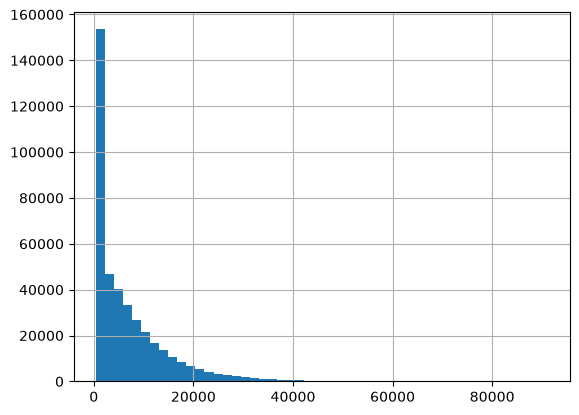

In [ ]:
df['max_monthly_emi'].hist(bins=50)

In [ ]:
both_missing = df['monthly_rent'].isna() & df['bank_balance'].isna()
print(both_missing.sum())

15


In [ ]:
df['age'] = df['age'].astype(str).str.replace(r'(\.\d+)\.\d+$', r'\1', regex=True)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print(df['age'].isna().sum())

0


In [ ]:
for col in ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']:
    df[col] = df[col].fillna(df[col].median())

df['education'] = df['education'].fillna('Unknown')

print(df.isnull().sum().sum())

TypeError: Cannot convert ['303200.0' '92500.0' '672100.0' ... '191600.0' '170400.0' '214400.0'] to numeric

In [ ]:
for col in ['monthly_rent', 'bank_balance', 'credit_score', 'emergency_fund']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df['education'] = df['education'].fillna('Unknown')

print(df.isnull().sum().sum())

0


In [ ]:
df.to_csv("../data/processed/emi_cleaned.csv", index=False)

In [ ]:
df['debt_to_income_ratio'] = (df['current_emi_amount'] + df['monthly_rent']) / df['monthly_salary']

df['loan_to_income_ratio'] = df['requested_amount'] / (df['monthly_salary'] * 12)

df['disposable_income'] = df['monthly_salary'] - (
    df['monthly_rent'] + df['school_fees'] + df['college_fees'] +
    df['travel_expenses'] + df['groceries_utilities'] +
    df['other_monthly_expenses'] + df['current_emi_amount']
)

df['savings_rate'] = df['bank_balance'] / df['monthly_salary']

df['dependents_ratio'] = df['dependents'] / df['family_size']

print(df[['debt_to_income_ratio', 'loan_to_income_ratio', 'disposable_income', 'savings_rate', 'dependents_ratio']].describe())